In [19]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
# import data
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<Axes: xlabel='age', ylabel='fare'>

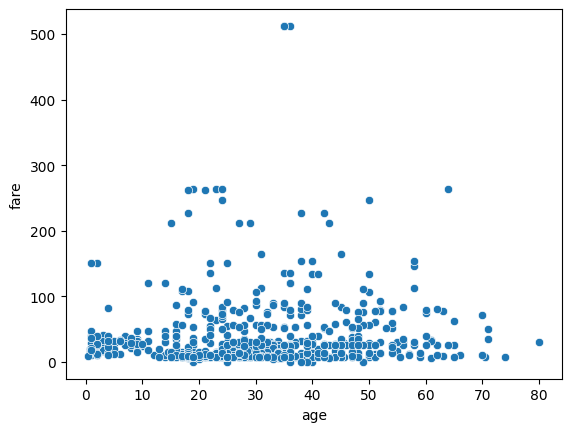

In [21]:
sns.scatterplot(data=df, x='age', y='fare')

In [22]:
# split the data
X = df[['age']].fillna(df['age'].mean())
y = df['fare']

In [23]:
# split the data into train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [24]:
# call the model
model = LinearRegression()

In [25]:
# train the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
# make out model intercept
print(model.intercept_)
print(model.coef_)
print('y = ', model.intercept_, '+', model.coef_, '* X')

21.89876485408405
[0.29862869]
y =  21.89876485408405 + [0.29862869] * X


In [27]:
# predict the model
y_pred = model.predict(X_test)
y_pred

array([32.94802633, 32.94802633, 24.58642305, 26.07956649, 31.1562542 ,
       30.76777341, 33.8439124 , 33.54528371, 34.44116977, 28.16996731,
       24.58642305, 30.76777341, 30.76777341, 32.64939764, 28.76722469,
       43.10140174, 30.76777341, 30.76777341, 30.76777341, 33.54528371,
       30.76777341, 30.76777341, 30.26036813, 30.76777341, 30.76777341,
       23.98916567, 32.35076895, 30.76777341, 29.96173945, 28.76722469,
       31.1562542 , 26.37819518, 30.76777341, 39.81648617, 22.0241889 ,
       30.76777341, 27.27408125, 39.21922879, 34.14254109, 27.57270994,
       32.94802633, 39.81648617, 26.67682387, 39.51785748, 26.67682387,
       35.33705584, 29.06585338, 29.06585338, 38.02471404, 30.76777341,
       32.35076895, 29.66311076, 34.44116977, 28.76722469, 36.23294191,
       31.1562542 , 35.03842715, 30.76777341, 29.36448207, 35.48637018,
       35.93431322, 30.76777341, 32.35076895, 31.45488289, 30.26036813,
       30.76777341, 36.83019928, 43.99728781, 27.87133863, 33.54

In [30]:
# evaluate the model
print("MSE = ", mean_squared_error, y_test, y_pred)
print("R2 = ", r2_score, y_test, y_pred)
print("RMSE = ", np.sqrt(mean_squared_error(y_test, y_pred)))

MSE =  <function mean_squared_error at 0x00000222E20AE480> 503     9.5875
137    53.1000
480    46.9000
39     11.2417
328    20.5250
        ...   
690    57.0000
122    30.0708
336    66.6000
738     7.8958
492    30.5000
Name: fare, Length: 179, dtype: float64 [32.94802633 32.94802633 24.58642305 26.07956649 31.1562542  30.76777341
 33.8439124  33.54528371 34.44116977 28.16996731 24.58642305 30.76777341
 30.76777341 32.64939764 28.76722469 43.10140174 30.76777341 30.76777341
 30.76777341 33.54528371 30.76777341 30.76777341 30.26036813 30.76777341
 30.76777341 23.98916567 32.35076895 30.76777341 29.96173945 28.76722469
 31.1562542  26.37819518 30.76777341 39.81648617 22.0241889  30.76777341
 27.27408125 39.21922879 34.14254109 27.57270994 32.94802633 39.81648617
 26.67682387 39.51785748 26.67682387 35.33705584 29.06585338 29.06585338
 38.02471404 30.76777341 32.35076895 29.66311076 34.44116977 28.76722469
 36.23294191 31.1562542  35.03842715 30.76777341 29.36448207 35.48637018
 35.93

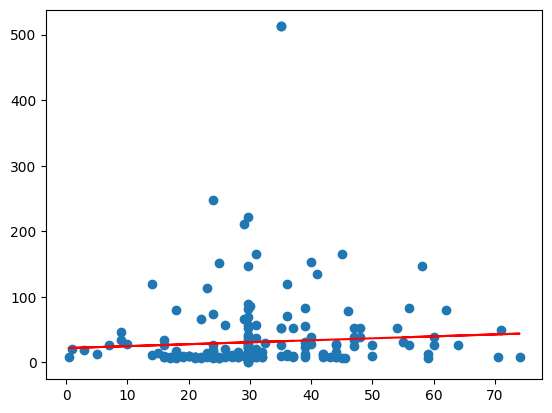

In [33]:
# plot the model and data
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color='red')
plt.show()